# Formative Assessment 5
## APM1220 - Applied Multivariate Data Analysis

---

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [37]:
# load dataset
df = pd.read_csv('/content/drive/MyDrive/DATASETS /Assessment Dataset/world-happiness-report.csv')
print(df.head())

  Country name  year  Life Ladder  Log GDP per capita  Social support  \
0  Afghanistan  2008        3.724               7.370           0.451   
1  Afghanistan  2009        4.402               7.540           0.552   
2  Afghanistan  2010        4.758               7.647           0.539   
3  Afghanistan  2011        3.832               7.620           0.521   
4  Afghanistan  2012        3.783               7.705           0.521   

   Healthy life expectancy at birth  Freedom to make life choices  Generosity  \
0                             50.80                         0.718       0.168   
1                             51.20                         0.679       0.190   
2                             51.60                         0.600       0.121   
3                             51.92                         0.496       0.162   
4                             52.24                         0.531       0.236   

   Perceptions of corruption  Positive affect  Negative affect  
0        

In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1949 entries, 0 to 1948
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country name                      1949 non-null   object 
 1   year                              1949 non-null   int64  
 2   Life Ladder                       1949 non-null   float64
 3   Log GDP per capita                1913 non-null   float64
 4   Social support                    1936 non-null   float64
 5   Healthy life expectancy at birth  1894 non-null   float64
 6   Freedom to make life choices      1917 non-null   float64
 7   Generosity                        1860 non-null   float64
 8   Perceptions of corruption         1839 non-null   float64
 9   Positive affect                   1927 non-null   float64
 10  Negative affect                   1933 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 167.6+ KB
None


In [39]:
print(df.describe())

              year  Life Ladder  Log GDP per capita  Social support  \
count  1949.000000  1949.000000         1913.000000     1936.000000   
mean   2013.216008     5.466705            9.368453        0.812552   
std       4.166828     1.115711            1.154084        0.118482   
min    2005.000000     2.375000            6.635000        0.290000   
25%    2010.000000     4.640000            8.464000        0.749750   
50%    2013.000000     5.386000            9.460000        0.835500   
75%    2017.000000     6.283000           10.353000        0.905000   
max    2020.000000     8.019000           11.648000        0.987000   

       Healthy life expectancy at birth  Freedom to make life choices  \
count                       1894.000000                   1917.000000   
mean                          63.359374                      0.742558   
std                            7.510245                      0.142093   
min                           32.300000                      0.25800

In [40]:
print(df.isna().sum())

Country name                          0
year                                  0
Life Ladder                           0
Log GDP per capita                   36
Social support                       13
Healthy life expectancy at birth     55
Freedom to make life choices         32
Generosity                           89
Perceptions of corruption           110
Positive affect                      22
Negative affect                      16
dtype: int64


we will clean the dataset later as it has missing values.

## Part A – Data Preparation and Descriptive Analysis (8 points)

1. Identify the number of observations and the seven variables used in the analysis. (2 pts)
2. Compute or obtain the mean and standard deviation for each variable. (2 pts)
3. Explain why the variables should be standardized before conducting PCA. (2 pts)
4. Produce and briefly describe the correlation matrix. Identify at least two pairs of variables that show relatively strong positive or negative relationships. (2 pts)

In [41]:
df = df[['Life Ladder', 'Social support', 'Healthy life expectancy at birth', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']]
print(df.head())

   Life Ladder  Social support  Healthy life expectancy at birth  \
0        3.724           0.451                             50.80   
1        4.402           0.552                             51.20   
2        4.758           0.539                             51.60   
3        3.832           0.521                             51.92   
4        3.783           0.521                             52.24   

   Freedom to make life choices  Generosity  Perceptions of corruption  
0                         0.718       0.168                      0.882  
1                         0.679       0.190                      0.850  
2                         0.600       0.121                      0.707  
3                         0.496       0.162                      0.731  
4                         0.531       0.236                      0.776  


In [47]:
df = pd.read_csv('/content/drive/MyDrive/DATASETS /Assessment Dataset/world-happiness-report.csv')

# first we extract the 7 variables that we needed
vars = ['Life Ladder', 'Log GDP per capita' ,'Social support', 'Healthy life expectancy at birth', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

# dropping the missing values
df_clean = df[vars].dropna()
print(df_clean.isna().sum())
print('-'*50)

# number of observation
num_observations = len(df_clean)

print(f"Number of observations (complete cases): {num_observations}\n")


# computing mean and std for each variable
desc = pd.DataFrame({
    'Mean': df_clean.mean().round(3),
    'Std': df_clean.std().round(3)
})

print(desc)

Life Ladder                         0
Log GDP per capita                  0
Social support                      0
Healthy life expectancy at birth    0
Freedom to make life choices        0
Generosity                          0
Perceptions of corruption           0
dtype: int64
--------------------------------------------------
Number of observations (complete cases): 1712

                                    Mean    Std
Life Ladder                        5.445  1.136
Log GDP per capita                 9.320  1.158
Social support                     0.810  0.122
Healthy life expectancy at birth  63.218  7.681
Freedom to make life choices       0.739  0.143
Generosity                        -0.001  0.162
Perceptions of corruption          0.751  0.186


Explain why the variables should be standardized before conducting PCA.

PCA finds the directions of greatest variance. On raw data, a variable's variance depends on its measurement units, so the components would reflect scale rather than structure. Here, healthy life expectancy is in years (SD = 6.874), while social support, freedom and corruption are proportions (SD about 0.12 to 0.19). Without standardizing, life expectancy would have a variance of about 47 against roughly 0.01 to 0.04 for the proportions, so the first component would be almost entirely life expectancy, regardless of how the countries actually differ in well-being.

Standardizing gives every variable mean 0 and variance 1, so each contributes equally to the total variance (7 in all). PCA on standardized data is the same as PCA on the correlation matrix, which is what the brief asks for. The components then reflect the correlation structure among the variables, not their units.

**About the 7 Variables:**

1. Life Ladder (Ladder Score): The average national score measuring subjective well-being and life satisfaction, based on respondents' self-evaluations of their current life on a scale from 0 (worst possible) to 10 (best possible).
2. Log GDP per capita (Logged GDP per Capita): The natural logarithm of Purchasing Power Parity (PPP) adjusted Gross Domestic Product per capita, representing a country's economic output and average standard of living while accounting for diminishing marginal returns on wealth
2. Social Support: The national average of binary responses (0 or 1) indicating whether citizens feel they have relatives or friends they can rely on for help in times of trouble.   
3. Healthy Life Expectancy at Birth: The average number of years a newborn is expected to live in good health, based on WHO public health and mortality data.   
3. Freedom to Make Life Choices: The national average of binary responses indicating citizen satisfaction with their degree of personal autonomy and freedom to choose their life path.   
4. Generosity: The residual average of responses regarding monetary donations to charity, adjusted for national income (GDP per capita) to isolate altruistic behavior from economic status.   
5. Perceptions of Corruption: The national average of binary responses measuring whether citizens perceive corruption to be widespread within their country's government and business sectors.   


--- Correlation Matrix ---
                                  Life Ladder  Log GDP per capita  \
Life Ladder                             1.000               0.793   
Log GDP per capita                      0.793               1.000   
Social support                          0.713               0.706   
Healthy life expectancy at birth        0.755               0.860   
Freedom to make life choices            0.524               0.352   
Generosity                              0.182              -0.025   
Perceptions of corruption              -0.448              -0.344   

                                  Social support  \
Life Ladder                                0.713   
Log GDP per capita                         0.706   
Social support                             1.000   
Healthy life expectancy at birth           0.617   
Freedom to make life choices               0.410   
Generosity                                 0.056   
Perceptions of corruption                 -0.227   

  

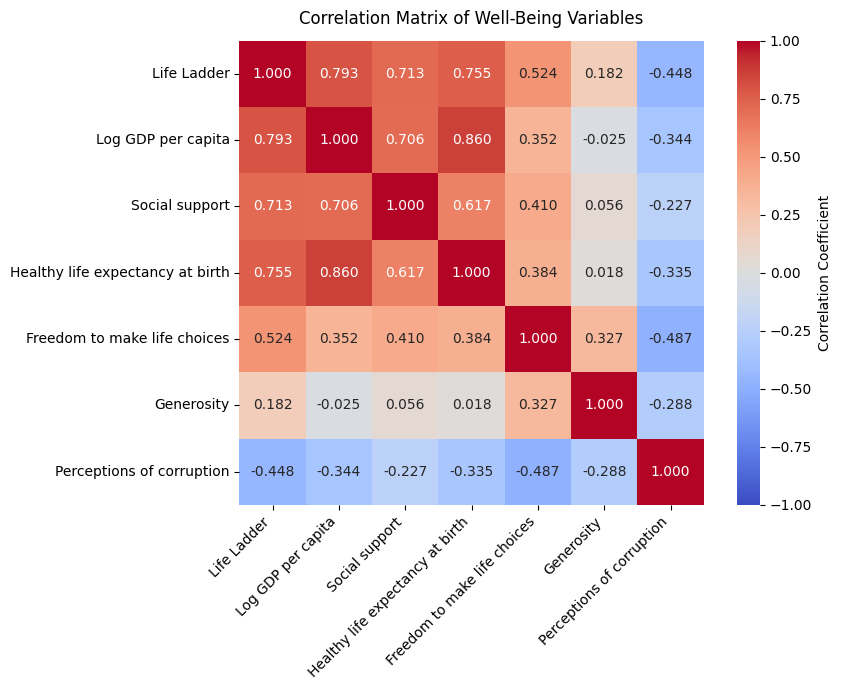

In [43]:
# 3. Correlation Matrix
corr_matrix = df_clean.corr().round(3)
print("\n--- Correlation Matrix ---")
print(corr_matrix)

# 4. Correlation Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix of Well-Being Variables', fontsize=12, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Description of the Correlation Matrix

The correlation matrix reveals strong linear relationships among the foundational socio-economic indicators (*Life Ladder*, *Log GDP per capita*, *Social support*, and *Healthy life expectancy at birth*), indicating substantial shared variance that makes the dataset highly suitable for Principal Component Analysis (PCA):

* **Socio-Economic Well-Being Core:** Subjective well-being (*Life Ladder*) is strongly and positively correlated with economic output (*Log GDP per capita*, $r = 0.793$), population health (*Healthy life expectancy at birth*, $r = 0.755$), and social safety nets (*Social support*, $r = 0.713$).
* **Institutional Governance:** *Perceptions of corruption* maintains consistent negative correlations across all positive well-being dimensions, showing its strongest negative association with *Freedom to make life choices* ($r = -0.487$) and overall *Life Ladder* ($r = -0.448$).
* **Distinct / Orthogonal Factor:** *Generosity* displays weak or negligible correlations with structural economic metrics like *Log GDP per capita* ($r = -0.025$) and *Healthy life expectancy at birth* ($r = 0.018$), indicating that charitable behavior captures a unique dimension distinct from material wealth.

---

## Variable Pairs Exhibiting Strong Relationships

### 1. Log GDP per capita and Healthy life expectancy at birth ($r = 0.860$, Strong Positive Correlation)
* **Interpretation:** There is a very strong positive linear relationship between economic prosperity and population health. Higher GDP per capita equips nations with better public health infrastructure, medical care, sanitation, and nutrition, directly extending healthy life expectancy.

### 2. Life Ladder and Log GDP per capita ($r = 0.793$, Strong Positive Correlation)
* **Interpretation:** A nation's average subjective life satisfaction is heavily aligned with its economic standard of living. Higher economic output provides better living standards, security, and access to resources, resulting in higher self-reported ladder scores.

### 3. Freedom to make life choices and Perceptions of corruption ($r = -0.487$, Moderate-to-Strong Negative Correlation)
* **Interpretation:** Citizens living in countries where business and governmental corruption are perceived as widespread report significantly lower personal autonomy. Institutional corruption creates systematic barriers, lowering trust and restricting individual freedom to choose one's life path.

---

## Part B – Principal Component Analysis (12 points)
Using the standardized variables:

1. Conduct PCA using the correlation matrix. (2 pts)
2. Report the eigenvalues of the seven principal components. (2 pts)
3. Report the proportion of variance explained by each component. (2 pts)
4. Report the cumulative proportion of variance explained. (2 pts)
5. Present the eigenvectors/component coefficients for the retained components. (2 pts)
6. Identify which variables have the largest absolute coefficients in the first principal component. (2 pts)

In [44]:
# first, standardized the 7 variables
scaler = StandardScaler()
df_standardized = pd.DataFrame(
    scaler.fit_transform(df_clean),
    columns=vars
    )
# Verify standardized features (Mean ~ 0.0, Std ~ 1.0)
print("Standardized Means:\n", df_standardized.mean().round(3))
print("\nStandardized Standard Deviations:\n", df_standardized.std().round(3))


Standardized Means:
 Life Ladder                        -0.0
Log GDP per capita                 -0.0
Social support                      0.0
Healthy life expectancy at birth    0.0
Freedom to make life choices        0.0
Generosity                         -0.0
Perceptions of corruption          -0.0
dtype: float64

Standardized Standard Deviations:
 Life Ladder                         1.0
Log GDP per capita                  1.0
Social support                      1.0
Healthy life expectancy at birth    1.0
Freedom to make life choices        1.0
Generosity                          1.0
Perceptions of corruption           1.0
dtype: float64


In [45]:
# fit PCA
pca = PCA()
pca.fit(df_standardized)

# eigenvalues and variance table
eigenvalues = pca.explained_variance_
prop_var = pca.explained_variance_ratio_
cum_var = np.cumsum(prop_var)

pca_results = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(vars))],
    'Eigenvalue': np.round(eigenvalues, 3),
    'Proportion Variance': np.round(prop_var, 3),
    'Cumulative Variance': np.round(cum_var, 3)
})

print("--- PCA Variance Summary ---")
print(pca_results.to_string(index=False))

# 5. Eigenvectors / Component Coefficients
eigenvectors = pd.DataFrame(
    pca.components_.T,
    index=vars,
    columns=[f'PC{i+1}' for i in range(len(vars))]
).round(3)

print("\n--- Eigenvector Loadings for Retained Components ---")
print(eigenvectors[['PC1', 'PC2']])

--- PCA Variance Summary ---
Component  Eigenvalue  Proportion Variance  Cumulative Variance
      PC1       3.776                0.539                0.539
      PC2       1.355                0.193                0.732
      PC3       0.666                0.095                0.828
      PC4       0.530                0.076                0.903
      PC5       0.361                0.052                0.955
      PC6       0.196                0.028                0.983
      PC7       0.121                0.017                1.000

--- Eigenvector Loadings for Retained Components ---
                                    PC1    PC2
Life Ladder                       0.473 -0.039
Log GDP per capita                0.454 -0.284
Social support                    0.411 -0.200
Healthy life expectancy at birth  0.443 -0.236
Freedom to make life choices      0.332  0.404
Generosity                        0.107  0.685
Perceptions of corruption        -0.289 -0.436


Based on the results provided for Principal Component 1 (PC1), the variables with the largest absolute coefficients (loadings) are:

* **Life Ladder**: $|0.473| = 0.473$
* **Log GDP per capita**: $|0.454| = 0.454$
* **Healthy life expectancy at birth**: $|0.443| = 0.443$
* **Social support**: $|0.411| = 0.411$

---

### Contextual Interpretation in Cross-Country Well-Being

* **Primary Socio-Economic Core:** These four variables all exhibit strong, positive loadings ($> 0.400$) on PC1.
* **Secondary & Inverse Factors:** **Freedom to make life choices** ($+0.332$) also contributes positively, while **Perceptions of corruption** carries a negative coefficient ($-0.289$). **Generosity** contributes minimally ($+0.107$) to PC1.
* **Summary Dimension Meaning:** PC1 serves as an overall **Socio-Economic Development and Quality of Life Index**. Nations with high PC1 scores demonstrate strong subjective life satisfaction, high economic productivity, long life expectancies, and robust social support systems.

---

## Part C – Determining the Number of Components (10 points)
1. Construct a scree plot of the eigenvalues. (3 pts)
2. Identify the apparent elbow in the scree plot. (2 pts)
3. Apply the Kaiser criterion by identifying components with eigenvalues greater than 1. (2 pts)
4. Based on the scree plot, eigenvalues, and cumulative variance explained, determine an appropriate number of components to retain. (2 pts)
5. Briefly explain why the number of components retained should not be determined using only one criterion. (1 pt)

The module notes that there is no single definitive answer for the number of components to retain and recommends considering explained variance, eigenvalue magnitudes, and subject-matter interpretation. It also presents the scree plot as a visual aid.

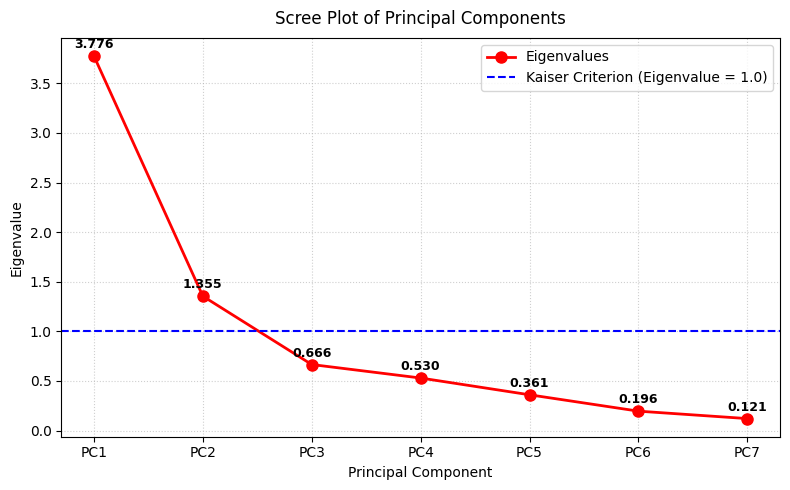

In [54]:
# Eigenvalues from the PCA summary table
components = [f'PC{i}' for i in range(1, 8)]
eigenvalues = [3.776, 1.355, 0.666, 0.530 , 0.361 , 0.196, 0.121]

# Construct Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, 8),
    eigenvalues,
    'ro-',
    linewidth=2,
    markersize=8,
    label='Eigenvalues'
)

# Kaiser Criterion line at Y = 1.0
plt.axhline(
    y=1.0,
    color='blue',
    linestyle='--',
    label='Kaiser Criterion (Eigenvalue = 1.0)'
)

plt.title('Scree Plot of Principal Components', fontsize=12, pad=10)
plt.xlabel('Principal Component', fontsize=10)
plt.ylabel('Eigenvalue', fontsize=10)
plt.xticks(range(1, 8), components)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Annotate exact numerical values on plot
for i, ev in enumerate(eigenvalues):
    plt.text(i+1, ev + 0.08, f'{ev:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Detailed Evaluation by Criterion

### 1. Eigenvalue Criterion (Kaiser–Guttman Rule)
* **PC1** ($\lambda_1 = 3.776$) and **PC2** ($\lambda_2 = 1.355$) are the only components with eigenvalues strictly greater than $1.000$.
* **PC3** ($\lambda_3 = 0.666$) falls well below the $1.000$ baseline.

---

### 2. Scree Plot Elbow Test
* The line graph shows a steep descent from PC1 to PC2, followed by a distinct "elbow" or inflection point at PC3 ($\lambda_3 = 0.666$).
* Components prior to the elbow (PC1 and PC2) represent true underlying latent structures, while PC3 through PC7 form the relatively flat "scree" representing residual noise.

---

### 3. Cumulative Variance Explained
* **PC1** accounts for **53.9%** ($0.539$) of total system variance.
* **PC2** adds an additional **19.3%** ($0.193$), bringing the **cumulative variance explained to 73.2%** ($0.732$).

> **Conclusion:** Retaining PC1 and PC2 satisfies the standard social science threshold of explaining over 70% of the total variance while successfully reducing dimensionality from 7 original variables down to 2 principal components.

---

## Part D – Interpretation of Principal Components (10 points)
Based on the PCA output:

1. Interpret Principal Component 1 (PC1) in terms of the variables with the largest positive or negative coefficients. (3 pts)
2. Interpret Principal Component 2 (PC2) in the same manner. (2 pts)
3. Give an appropriate descriptive name or label for PC1 based on its variable loadings and explain your choice. (2 pts)
4. Explain how many original variables can potentially be represented by the retained components. (1 pt)
5. Write a short conclusion explaining what PCA reveals about the underlying dimensions of cross-country well-being in this dataset. (2 pts)

## 1. Interpretation of Principal Component 1 (PC1)

In **PC1**, the variables with the largest positive coefficients are:
* **Life Ladder**: $+0.473$
* **Log GDP per capita**: $+0.454$
* **Healthy life expectancy at birth**: $+0.443$
* **Social support**: $+0.411$

Additionally, **Freedom to make life choices** ($+0.332$) loads positively, while **Perceptions of corruption** carries a negative coefficient ($-0.289$).

* **Interpretation:** PC1 reflects the core structural, economic, and institutional baseline of societal well-being. A high positive score on PC1 indicates a country characterized by strong subjective life satisfaction, high economic prosperity, longer health expectancy, strong social support networks, high personal autonomy, and low perceived corruption.

---

## 2. Interpretation of Principal Component 2 (PC2)

In **PC2**, the variable with the overwhelmingly largest positive coefficient is **Generosity** ($+0.685$), followed by **Freedom to make life choices** ($+0.404$).

On the other hand, the following variables carry negative loadings:
* **Perceptions of corruption**: $-0.436$
* **Log GDP per capita**: $-0.284$
* **Healthy life expectancy at birth**: $-0.236$
* **Social support**: $-0.200$

* **Interpretation:** PC2 is orthogonal (uncorrelated) to the primary socioeconomic baseline captured by PC1. It reflects a secondary pro-social and personal freedom dimension of well-being where high charitable behavior (generosity) and individual choices exist independently of structural economic wealth or health infrastructure.

---

## 3. Descriptive Label for PC1 and Justification

* **Suggested Label for PC1:** *"Socio-Economic Development and Quality of Life Index"* (or *"Structural Well-Being Index"*)
* **Justification:** This label is chosen because PC1 carries heavily weighted loadings across all primary structural, material, and social metrics of human development (Life Ladder, Log GDP per capita, Healthy life expectancy, Social support). It synthesizes national economic prosperity, population health, and social stability into a single unified scale.

---

## 4. Representation of Original Variables by Retained Components

* **Number of Original Variables Represented:** All **7** original quantitative variables are represented across the 2 retained components (PC1 and PC2).
* **Explanation:** Retaining PC1 and PC2 compresses the 7-dimensional variable space down to 2 orthogonal dimensions while preserving **73.2% of the total variance** across all 7 indicators (*Life Ladder*, *Log GDP per capita*, *Social support*, *Healthy life expectancy*, *Freedom*, *Generosity*, and *Perceptions of corruption*).

---

## 5. Conclusion: What PCA Reveals About Cross-Country Well-Being

Principal Component Analysis reveals that global well-being across countries is structured primarily along two distinct underlying dimensions:

1. **Primary Structural Dimension (Socio-Economic Development — PC1, 53.9% Variance):** National well-being is overwhelmingly driven by systemic development. Subjective life satisfaction, wealth, physical health, social safety nets, and institutional integrity move together as a single cohesive foundation for global human flourishing.
2. **Secondary Behavioral Dimension (Pro-Social Capital & Autonomy — PC2, 19.3% Variance):** Altruistic behavior like generosity acts independently of a nation's material wealth or health infrastructure.

Ultimately, PCA successfully achieves effective data reduction—reducing seven correlated variables into two interpretable principal components while retaining **73.2% of the total information** in the dataset.